# ResNet-18

In [ ]:
import os
import copy
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import copy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

DATA_DIR = "/kaggle/input/datasets/phtk19hcmnguyngia/chinese-and-western-face-emo/Balanced"

BATCH_SIZE = 32
EPOCHS = 50
FREEZE_EPOCHS = 4
LR = 3e-4
PATIENCE = 7
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# DATASET SPLIT
image_paths = []
labels = []

classes = sorted(os.listdir(DATA_DIR))
class_to_idx = {c:i for i,c in enumerate(classes)}

for c in classes:
    class_dir = os.path.join(DATA_DIR, c)
    for img in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img))
        labels.append(class_to_idx[c])

image_paths = np.array(image_paths)
labels = np.array(labels)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train:", len(train_paths))
print("Test:", len(val_paths))


# DATASET CLASS
class EmotionDataset(Dataset):

    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):

        img = Image.open(self.paths[idx]).convert("RGB")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


# DATA AUGMENTATION
train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(0, translate=(0.05,0.05)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


train_dataset = EmotionDataset(train_paths, train_labels, train_tf)
test_dataset = EmotionDataset(val_paths, val_labels, test_tf)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


# MODEL
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, len(classes))
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.3,
    patience=3,
)


# TRAIN FUNCTION
def train_epoch(loader):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for x, y in loader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        out = model(x)

        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss/len(loader), correct/total


def validate_epoch(loader):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for x, y in loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            out = model(x)

            loss = criterion(out, y)

            total_loss += loss.item()

            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss/len(loader), correct/total


# TRAIN LOOP
best_loss = float("inf")
patience_counter = 0
best_model = None

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(EPOCHS):

    if epoch == FREEZE_EPOCHS:

        print("Unfreezing backbone...")

        for param in model.parameters():
            param.requires_grad = True

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=LR/10,
            weight_decay=1e-4
        )

    train_loss, train_acc = train_epoch(train_loader)
    test_loss, test_acc = validate_epoch(test_loader)

    scheduler.step(test_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    if test_loss < best_loss:

        best_loss = test_loss
        patience_counter = 0

        best_model = copy.deepcopy(model.state_dict())

        torch.save(best_model, "resnet.pt")

        print("Saved best model")

    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print("Early stopping triggered")
        break

Train: 9913
Test: 2479

Epoch 1/50
Train Loss: 0.8955 | Train Acc: 0.6754
Test Loss: 0.7677 | Test Acc: 0.7362
Saved best model

Epoch 2/50
Train Loss: 0.7298 | Train Acc: 0.7675
Test Loss: 0.7292 | Test Acc: 0.7648
Saved best model

Epoch 3/50
Train Loss: 0.6816 | Train Acc: 0.7866
Test Loss: 0.7006 | Test Acc: 0.7753
Saved best model

Epoch 4/50
Train Loss: 0.6450 | Train Acc: 0.8050
Test Loss: 0.7105 | Test Acc: 0.7822
Unfreezing backbone...

Epoch 5/50
Train Loss: 0.5548 | Train Acc: 0.8550
Test Loss: 0.6640 | Test Acc: 0.7979
Saved best model

Epoch 6/50
Train Loss: 0.5113 | Train Acc: 0.8762
Test Loss: 0.6755 | Test Acc: 0.7979

Epoch 7/50
Train Loss: 0.4726 | Train Acc: 0.8985
Test Loss: 0.6793 | Test Acc: 0.7999

Epoch 8/50
Train Loss: 0.4465 | Train Acc: 0.9127
Test Loss: 0.6989 | Test Acc: 0.7991

Epoch 9/50
Train Loss: 0.4209 | Train Acc: 0.9248
Test Loss: 0.6959 | Test Acc: 0.8060

Epoch 10/50
Train Loss: 0.3941 | Train Acc: 0.9343
Test Loss: 0.7223 | Test Acc: 0.8011

Epoc

In [12]:
model.load_state_dict(best_model)
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(DEVICE)

        out = model(x)
        probs = torch.softmax(out, dim=1).cpu().numpy()

        preds = np.argmax(probs, axis=1)

        y_pred.extend(preds)
        y_true.extend(y.numpy())
        y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("\nClassification Report\n")
print(classification_report(y_true, y_pred, target_names=classes))


Classification Report

              precision    recall  f1-score   support

       anger       0.75      0.76      0.76       516
        fear       0.76      0.73      0.74       515
       happy       0.92      0.91      0.91       516
     neutral       0.91      0.90      0.91       516
         sad       0.62      0.66      0.64       416

    accuracy                           0.80      2479
   macro avg       0.79      0.79      0.79      2479
weighted avg       0.80      0.80      0.80      2479



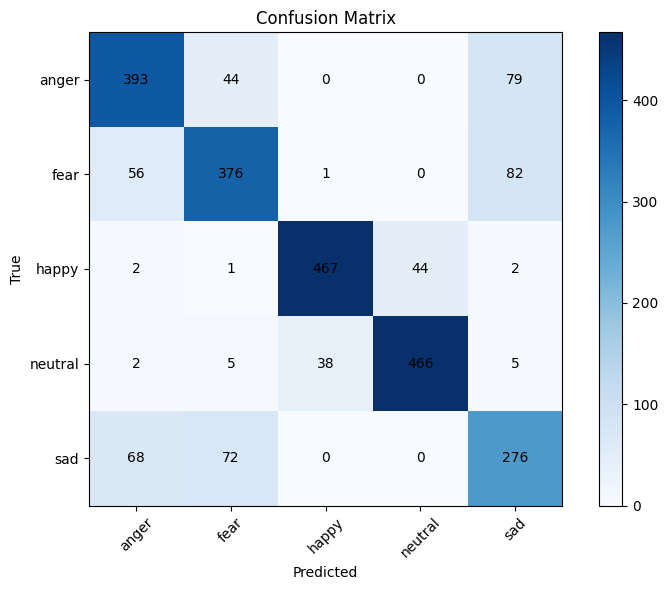

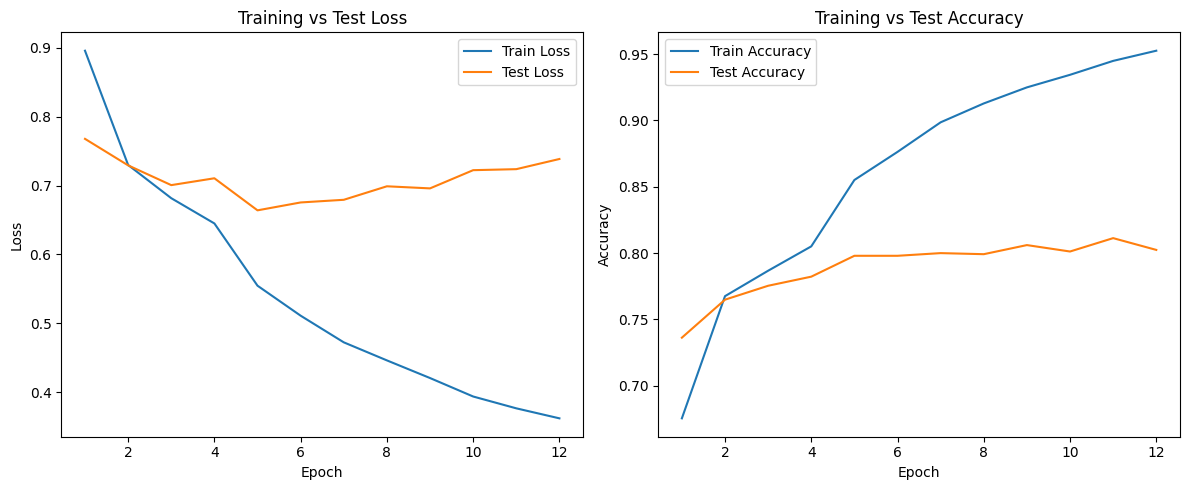

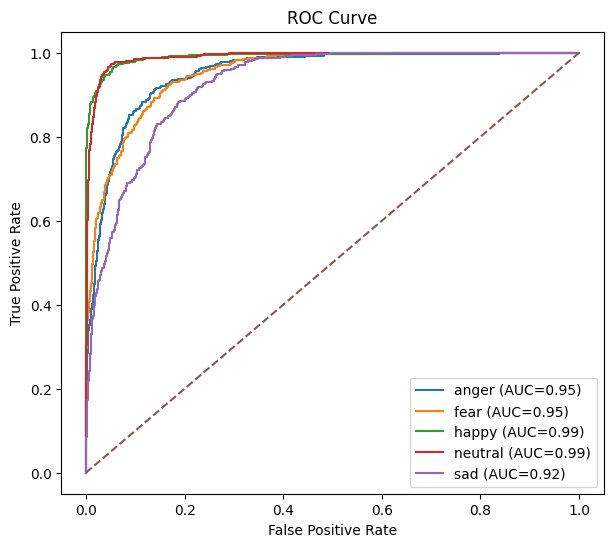

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(len(classes)), classes, rotation=45)
plt.yticks(range(len(classes)), classes)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

# Train history
epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["test_loss"], label="Test Loss")
plt.title("Training vs Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["test_acc"], label="Test Accuracy")
plt.title("Training vs Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

# Roc Curve
y_true_bin = label_binarize(y_true, classes=range(len(classes)))

plt.figure(figsize=(7,6))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()